In [1]:
"""Set up model training and on one sample from A4 and A7 strains."""
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from sklearn.metrics import roc_curve, auc
sys.path.insert(0, str(Path("src").resolve()))
from load_df       import load_K9, load_TE_map, build_te_df, sample_negatives, build_full_df
from load_tensors  import make_tensors, make_splits
from simple_K9_CNN import train, predict, K9_CNN

DATA_DIR   = Path("test_data")
MODEL_PATH = Path("best_model.pth")

A4_k9    = load_K9(str(DATA_DIR / "A4_K9.bed"))
A7_k9    = load_K9(str(DATA_DIR / "A7_K9.bed"))
A4_to_A7 = load_TE_map(str(DATA_DIR / "A4_to_A7_map.txt"))
A7_to_A4 = load_TE_map(str(DATA_DIR / "A7_to_A4_map.txt"))

te_df   = build_te_df(A4_k9, A7_k9, A4_to_A7, A7_to_A4)
neg_df  = sample_negatives(te_df, A4_k9, A7_k9, neg_ratio=0.10)
full_df = build_full_df(te_df, neg_df)

train_df, val_df, test_df = make_splits(full_df)

model, history, test_metrics = train(
    train_df, val_df, test_df,
    batch_size=32, n_epochs=40, lr=1e-3, dropout=0.3,
    save_path=str(MODEL_PATH),
)

Device: cpu
Parameters: 20,002

Epoch   TrainLoss   ValLoss   bAcc_A4   bAcc_A7   auROC_A4   auROC_A7
---------------------------------------------------------------------------
  → saved best model (epoch 1)
    1      0.6722    0.6606     0.549     0.539      0.692      0.656
  → saved best model (epoch 2)
    2      0.6445    0.6368     0.622     0.617      0.728      0.681
  → saved best model (epoch 3)
    3      0.6277    0.6177     0.641     0.578      0.736      0.688
    4      0.6258    0.6204     0.631     0.620      0.752      0.699
  → saved best model (epoch 5)
    5      0.6174    0.6074     0.661     0.617      0.732      0.695
  → saved best model (epoch 6)
    6      0.6098    0.6063     0.650     0.633      0.749      0.706
  → saved best model (epoch 7)
    7      0.5899    0.5937     0.678     0.648      0.744      0.712
  → saved best model (epoch 8)
    8      0.5988    0.5877     0.638     0.609      0.746      0.712
    9      0.5883    0.5941     0.673     0.6

In [2]:
"""Dataset summary used for training."""
label_map = {(1, 0): "A4 only", (0, 1): "A7 only", (1, 1): "Both", (0, 0): "Negative"}
label_col = full_df.apply(lambda r: label_map[(int(r.label_A4), int(r.label_A7))], axis=1)
dist = label_col.value_counts().reindex(["A4 only", "A7 only", "Both", "Negative"]).fillna(0).astype(int)

summary = pd.DataFrame({
    "Count": [len(A4_to_A7), len(A7_to_A4), "-", "-", len(te_df), len(neg_df), len(full_df)],
}, index=["A4 mapped TEs (flag=1)", "A7 mapped TEs (flag=1)",
          "A4-only loci", "A7-only loci",
          "Total TE loci", "Negatives", "Total"])

split_summary = pd.DataFrame({
    "Samples": [len(train_df), len(val_df), len(test_df)],
}, index=["Train", "Val", "Test"])
summary.loc["A4-only loci", "Count"] = dist.get("A4 only", 0)
summary.loc["A7-only loci", "Count"] = dist.get("A7 only", 0)

print("Annotation & Dataset Counts")
display(summary)
print("Train / Val / Test Split")
display(split_summary)
print("Label Distribution")
display(dist.rename("Count").to_frame())

Annotation & Dataset Counts


,Count
A4 mapped TEs (flag=1),497
A7 mapped TEs (flag=1),471
A4-only loci,497
A7-only loci,471
Total TE loci,968
Negatives,96
Total,1064


Train / Val / Test Split


,Samples
Train,744
Val,160
Test,160


Label Distribution


,Count
A4 only,497
A7 only,471
Both,0
Negative,96


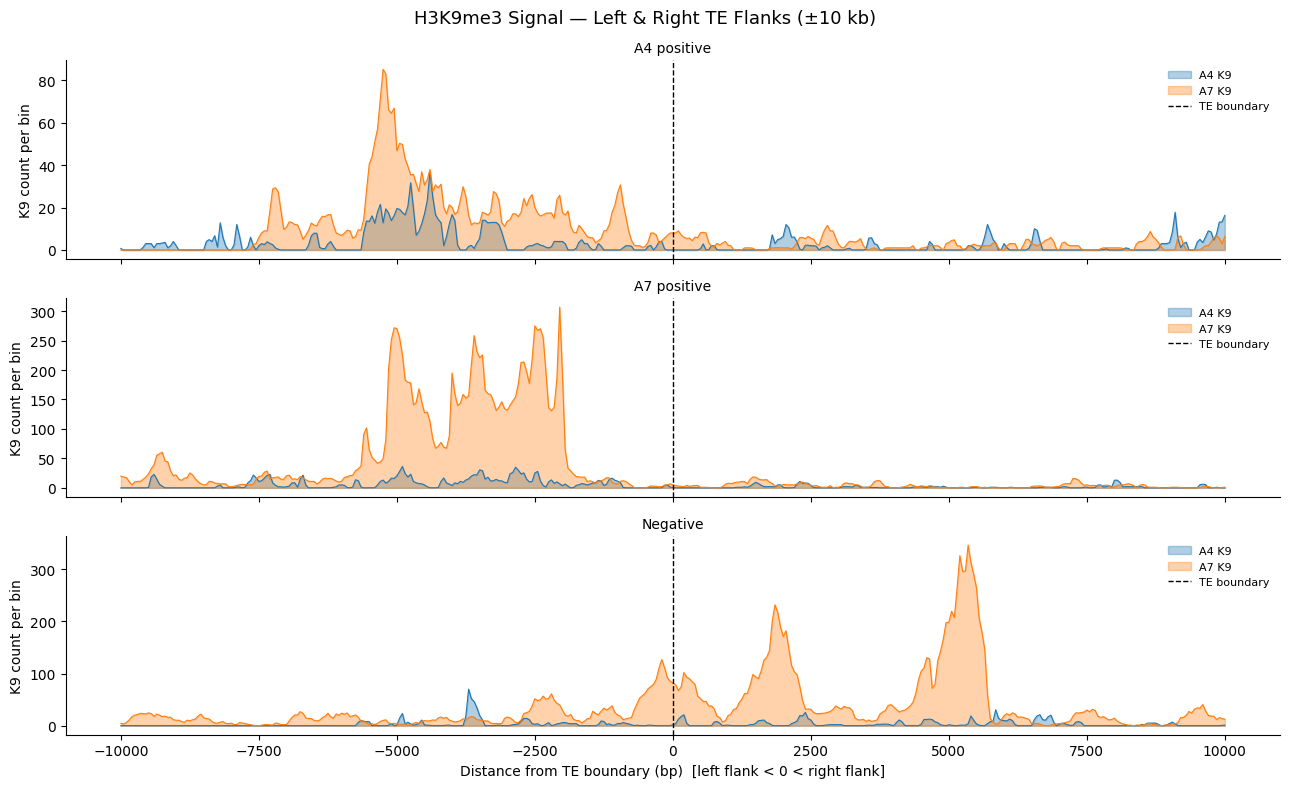

In [3]:
"""Show K9 count distributions for sample loci (left and right flanks)"""
examples = [
    (te_df[te_df["label_A4"] == 1].iloc[10], "A4 positive"),
    (te_df[te_df["label_A7"] == 1].iloc[10], "A7 positive"),
    (neg_df.iloc[10],                         "Negative"),
]

n_bins_per_side = len(te_df.iloc[30]["A4_K9"]) // 2
x_left  = np.linspace(-10_000, 0, n_bins_per_side + 1)[:-1]
x_right = np.linspace(0, 10_000, n_bins_per_side + 1)[1:]
x = np.concatenate([x_left, x_right])

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

for ax, (row, title) in zip(axes, examples):
    ax.fill_between(x, row["A4_K9"], alpha=0.35, color="tab:blue",   label="A4 K9")
    ax.fill_between(x, row["A7_K9"], alpha=0.35, color="tab:orange",  label="A7 K9")
    ax.plot(x, row["A4_K9"], color="tab:blue",   linewidth=0.8)
    ax.plot(x, row["A7_K9"], color="tab:orange",  linewidth=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0, label="TE boundary")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("K9 count per bin")
    ax.legend(loc="upper right", fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[-1].set_xlabel("Distance from TE boundary (bp)  [left flank < 0 < right flank]")
plt.suptitle("H3K9me3 Signal — Left & Right TE Flanks (±10 kb)", fontsize=13)
plt.tight_layout()
plt.show()

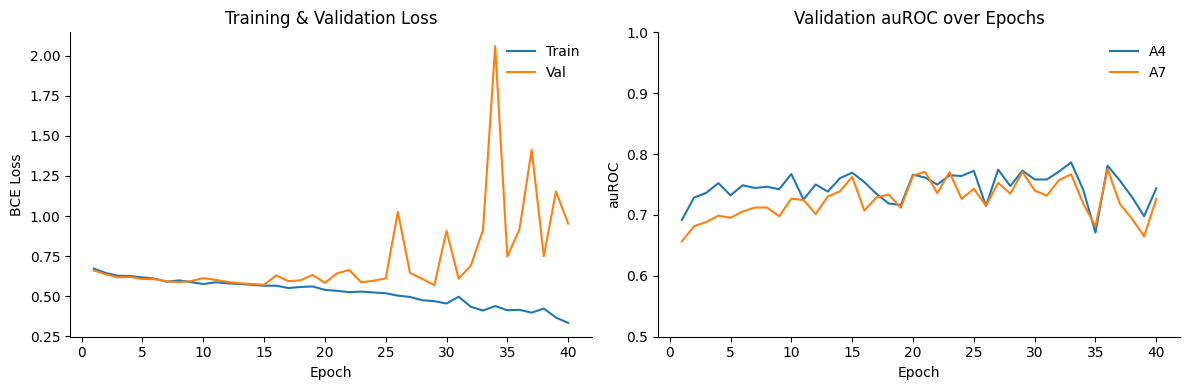

In [4]:
"""Show training vs. validation loss as well as auROC for the val set"""
epochs     = [h["epoch"]      for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss   = [h["loss"]       for h in history]
auroc_A4   = [h["auROC_A4"]   for h in history]
auroc_A7   = [h["auROC_A7"]   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Model seems to be overfitting based on validation loss
ax1.plot(epochs, train_loss, color="tab:blue",   label="Train")
ax1.plot(epochs, val_loss,   color="tab:orange",  label="Val")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend(frameon=False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
# auROC plateus around 0.85-0.9
ax2.plot(epochs, auroc_A4, color="tab:blue",   label="A4")
ax2.plot(epochs, auroc_A7, color="tab:orange",  label="A7")
ax2.set_ylim(0.5, 1.0)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("auROC")
ax2.set_title("Validation auROC over Epochs")
ax2.legend(frameon=False)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

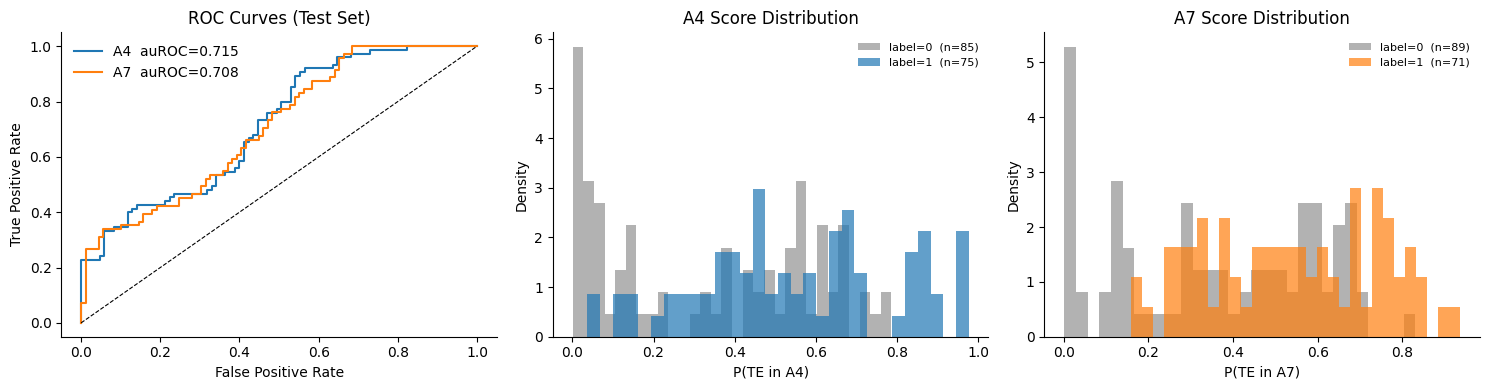

,auROC,bAcc
A4,0.715,0.590
A7,0.708,0.596


In [5]:
"""Show evaluation metrics using test dataset with a best_model determined by validation accuracy"""
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_model = K9_CNN(dropout=0.3).to(device)
best_model.load_state_dict(torch.load(str(MODEL_PATH), weights_only=True))

X_test, y_test = make_tensors(test_df)
test_loader    = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)
probs, labels  = predict(best_model, test_loader, device)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC curves
for i, (strain, color) in enumerate([("A4", "tab:blue"), ("A7", "tab:orange")]):
    fpr, tpr, _ = roc_curve(labels[:, i], probs[:, i])
    axes[0].plot(fpr, tpr, color=color, label=f"{strain}  auROC={auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (Test Set)")
axes[0].legend(frameon=False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Score distributions (Probability of TE vs. true label), I use threshold of 0.5. 
for ax, i, strain in [(axes[1], 0, "A4"), (axes[2], 1, "A7")]:
    for lv, color, alpha in [(0, "tab:gray", 0.6), (1, "tab:blue" if i == 0 else "tab:orange", 0.7)]:
        mask = labels[:, i] == lv
        ax.hist(probs[mask, i], bins=30, alpha=alpha, color=color,
                label=f"label={lv}  (n={mask.sum()})", density=True)
    ax.set_xlabel(f"P(TE in {strain})")
    ax.set_ylabel("Density")
    ax.set_title(f"{strain} Score Distribution")
    ax.legend(fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    "auROC": [test_metrics["auROC_A4"], test_metrics["auROC_A7"]],
    "bAcc":  [test_metrics["bAcc_A4"],  test_metrics["bAcc_A7"]],
}, index=["A4", "A7"])
display(metrics_df.round(3))